# Polars Part 2: Income Groups and Carbon Efficiency

This notebook rebuilds the core Polars workflow, adds income groups, and focuses on carbon-intensity comparisons and outlier detection.

Links:
- [Polars notebook overview](README.md)
- [Shared helpers](../functions.py)

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path
import sys


def find_repo_root(start: Path) -> Path:
    for candidate in [start] + list(start.parents):
        if (candidate / 'data' / 'co2_data.csv').exists() and (candidate / 'notebooks' / 'functions.py').exists():
            return candidate
    raise FileNotFoundError('Could not locate the repository root from the current working directory.')


REPO_ROOT = find_repo_root(Path.cwd().resolve())
NOTEBOOKS_DIR = REPO_ROOT / 'notebooks'
if str(NOTEBOOKS_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOKS_DIR))
DATA_DIR = REPO_ROOT / 'data'

import pandas as pd
import polars as pl
import numpy as np

import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import PartialDependenceDisplay
import umap.umap_ as umap

import timeit
import requests

from functions import (
    apply_correlation_to_df,
    normalize_column,
    z_score_column,
    safe_divide,
    classify_income_group,
    get_top_bottom_n,
    compute_energy_mix_shares,
    plot_dual_axis_timeseries,
    run_kmeans_elbow,
    fetch_wikipedia_gni_table,
    fetch_world_bank_xml_records,
)

# clean plotting defaults
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "legend.fontsize": 10,
    "figure.titlesize": 16,
})
%matplotlib inline


/Users/fabianfrank/Documents/carbon_analysis/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Setup

Import libraries and configure plot styling. We use `seaborn` for statistical graphics with a clean whitegrid theme, and `autoreload` to hot-reload helper functions from [functions.py](../functions.py) during development.

# Carbon Emissions and Economic Development: A Visual Analysis

The central question driving this analysis is whether economic growth necessarily comes at the cost of rising carbon emissions - or whether countries can **decouple** the two. This is one of the most consequential questions in climate policy: if decoupling is possible, it suggests that prosperity and sustainability are not mutually exclusive.

To investigate this, we combine two authoritative datasets:

1. **CO2 Emissions** (Our World in Data, 1750–2024) - historical emissions by country, measured in millions of tonnes
2. **GDP** (World Bank, 1960–2024) - economic output in current USD
3. **Electricity** (Our World in Data, 2000-2024) - Share of electricity production methods of the countries

By normalizing both metrics to per-capita values and computing Pearson correlations over time, we can classify countries along a spectrum: from those where growth and emissions move in lockstep (strong coupling) to those where GDP continues to rise while emissions fall (decoupling). We then ask whether this pattern is systematic - do high-income countries decouple more than low-income ones?

## CO2 Emissions Data

We load the Our World in Data CO2 dataset, which contains 79 columns spanning energy mix, land use, and emissions breakdowns. For this analysis we reduce it to five key variables: `country`, `year`, `iso_code`, `population`, and `co2` (total production-based CO2 emissions in millions of tonnes).

Two important filtering steps:
- **Drop rows without `iso_code`**: The dataset includes aggregate entities like "Africa", "OECD", and "World" that lack ISO country codes. Removing these ensures we work exclusively with individual nation-states.
- **Filter to post-1960**: GDP data from the World Bank only begins in 1960, so we align the time range to enable a clean merge later.

In [3]:
co2_df = pl.read_csv(DATA_DIR / 'co2_data.csv')

# choose what columns to keep (can be changed, but this is the most important)
selected_columns = ['country', 'year', 'iso_code', 'population', 'co2']

# drop the columns that are not in the selected_columns list
co2_df = co2_df.select(selected_columns)

# remove entries with no iso code(Continents and other groups)
co2_df = (
    co2_df
    .with_columns(pl.col("co2")
                    .str.strip_chars()
                    .replace("", None)
                    .cast(pl.Float64))
    
    .filter(pl.col("iso_code") != "")
    .filter(pl.col("year") > 1960))


co2_df


country,year,iso_code,population,co2
str,i64,str,i64,f64
"""Afghanistan""",1961,"""AFG""",9214082,0.491
"""Afghanistan""",1962,"""AFG""",9404410,0.689
"""Afghanistan""",1963,"""AFG""",9604491,0.707
"""Afghanistan""",1964,"""AFG""",9814317,0.839
"""Afghanistan""",1965,"""AFG""",10036003,1.007
…,…,…,…,…
"""Zimbabwe""",2020,"""ZWE""",15526887,8.491
"""Zimbabwe""",2021,"""ZWE""",15797220,10.223
"""Zimbabwe""",2022,"""ZWE""",16069061,12.232


## GDP Data

The World Bank GDP dataset arrives in **wide format** - one column per year (1960, 1961, ..., 2024). This is convenient for spreadsheet viewing but incompatible with tidy-data principles needed for plotting and merging. We use `pl.unipivot()` to reshape it into long format with one row per country-year observation.

Key steps:
- **Melt** year columns into `year` (int) and `gdp` (numeric) columns
- **Rename** `Country Code` to `iso_code` to create a shared merge key with the CO2 dataset
- **Drop missing GDP values** - not all countries have GDP records for every year, particularly in earlier decades or for newly independent states

In [4]:
# load GDP data
gdp_df = pl.read_csv(DATA_DIR / 'gdp_data.csv')

# reshape from wide to long format
# melt the year columns into rows
year_columns = [col for col in gdp_df.columns if col.isdigit()]
gdp_df = gdp_df.unpivot(
    index=['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code'],
    on=year_columns,
    variable_name='year',
    value_name='gdp')

# rename Country Code to iso_code for merging
gdp_df = gdp_df.rename({'Country Code': 'iso_code'})

# keep only the columns we need
gdp_df = gdp_df[['iso_code', 'year', 'gdp']]

gdp_df = (gdp_df
          .with_columns(pl.col("year").str.to_integer())
          .with_columns(pl.col("gdp").str.strip_chars().replace("", None).cast(pl.Float64))
          .drop_nulls(subset=["gdp"]))

gdp_df

iso_code,year,gdp
str,i64,f64
"""AFE""",1960,2.4206e10
"""AFW""",1960,1.1905e10
"""ARG""",1960,1.5865e10
"""AUS""",1960,1.8636e10
"""AUT""",1960,6.6241e9
…,…,…
"""WSM""",2024,1.1757e9
"""XKX""",2024,1.1197e10
"""ZAF""",2024,4.0114e11


## Merging the Datasets

We perform a **left join** of GDP onto the CO2 dataframe using `iso_code` and `year` as composite keys. A left join preserves every CO2 record and attaches GDP where available - countries or years without World Bank GDP data simply receive NaN. This is preferable to an inner join because it avoids silently discarding emission records that are still valuable for other analyses.

### Missing Data Heatmap

Before proceeding, we visualize data completeness. The heatmap below shows each variable as a column and each record as a row, with bright cells indicating missing values. This diagnostic is important because it reveals whether missingness is **random** or **systematic** - for instance, GDP data may be consistently absent for certain countries or time periods, which would bias any analysis that silently drops incomplete rows.

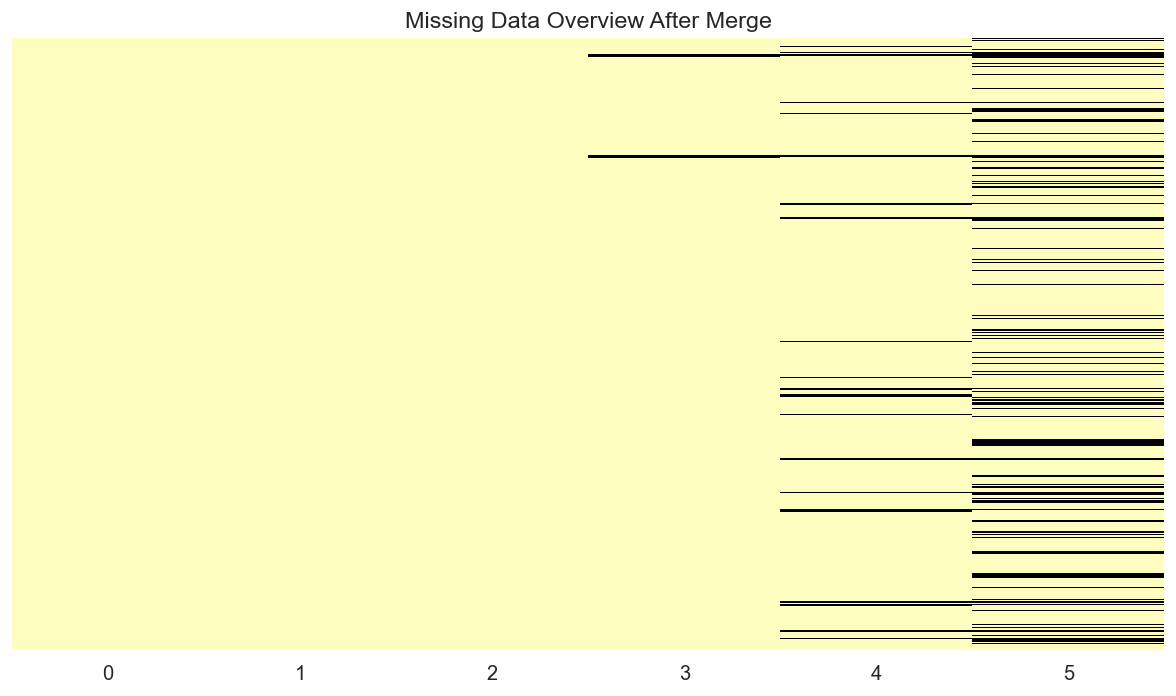

In [5]:
# merge the datasets on iso_code and year
base_df = co2_df.join(
    gdp_df,
    on=['iso_code', 'year'],
    how='left',)

# missing data heatmap
fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(base_df.select(pl.all().is_null()), yticklabels=False, cbar=False, cmap='magma_r', ax=ax)
ax.set_title("Missing Data Overview After Merge")

plt.tight_layout()
plt.show()

In [6]:
# return null values per column
base_df.select(pl.all().null_count())

country,year,iso_code,population,co2,gdp
u32,u32,u32,u32,u32,u32
0,0,0,128,677,2745


### Data Quality Summary

The GDP column shows the most missingness - this is expected since many countries (especially newly independent or conflict-affected states) lack World Bank GDP records in earlier decades. Importantly, the missingness is **systematic** rather than random: it concentrates in specific countries and time periods. This means any analysis involving GDP will implicitly exclude these observations, so conclusions are most robust for the subset of countries with consistent economic data.

## Per-Capita Metrics

Absolute CO2 and GDP figures are dominated by population size - China and India will always top the charts simply because they have the most people, not necessarily because their economies or industries are more carbon-intensive on a per-person basis. Dividing by population yields **per-capita** values that enable fairer cross-country comparisons: how much does the average citizen emit, and how wealthy is the average citizen?

- **CO2 per capita** is expressed in **tonnes per person** (the raw CO2 column is in millions of tonnes, so we multiply by 10⁶ before dividing by population).
- **GDP per capita** is in **current USD per person**.

We use `np.divide` with a `where` guard to handle zero or missing population entries without raising division errors.

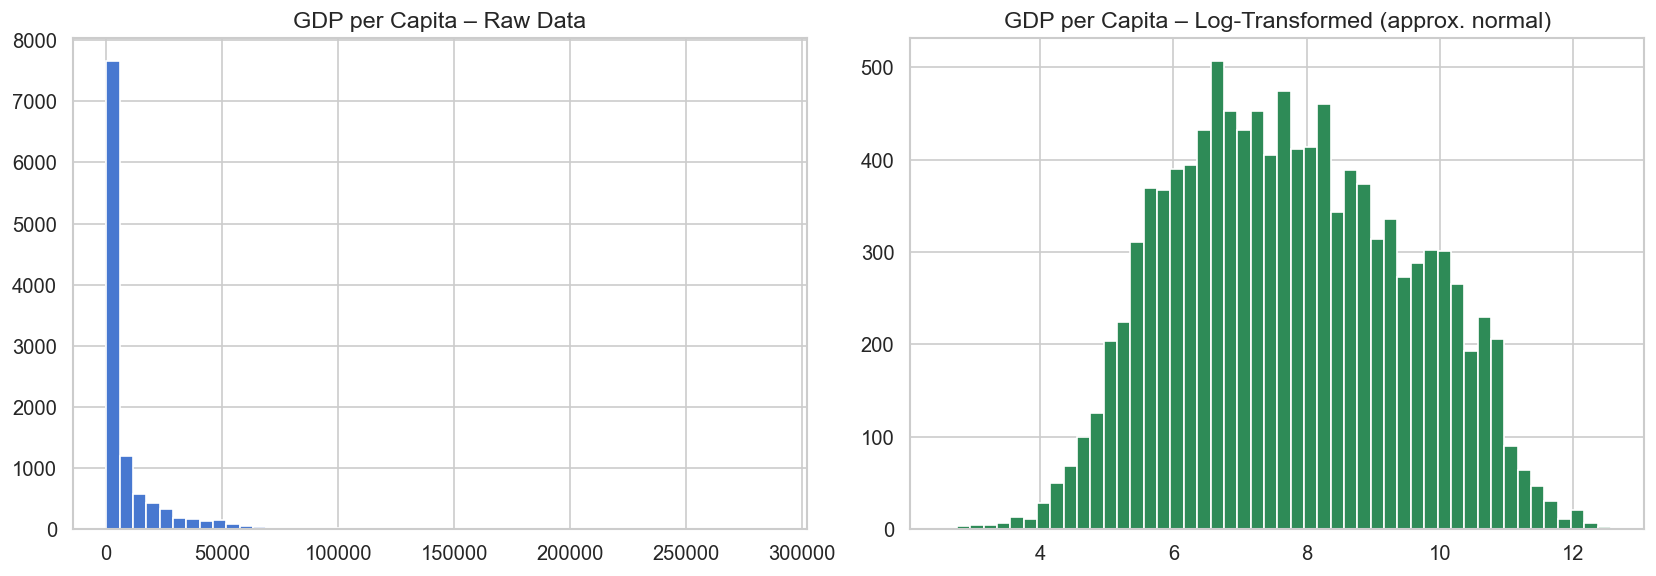

In [7]:
# CO2 is in millions of tonnes; multiply by 1e6 to get tonnes, then divide by population
base_df = base_df.with_columns(
    (pl.col("co2") / pl.col("population") * 1e6)
    .replace([float("inf"), -float("inf")], None)
    .alias("co2_per_capita"))

base_df = base_df.with_columns(
    (pl.col("gdp") / pl.col("population"))
    .replace([float("inf"), -float("inf")], None)
    .alias("gdp_per_capita"))

# Log-transform per-capita metrics for better visualization
base_df = base_df.with_columns(np.log1p(pl.col('gdp_per_capita'))
                               .alias("log_gdp_pc"))
base_df = base_df.with_columns(np.log1p(pl.col('co2_per_capita'))
                              .alias("log_co2_pc"))                     

# compare raw and log-transformed data as histograms
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(base_df.select("gdp_per_capita"), bins=50, edgecolor='white')
axes[0].set_title('GDP per Capita – Raw Data')
axes[1].hist(base_df.select("log_gdp_pc"), bins=50, edgecolor='white', color='seagreen')
axes[1].set_title('GDP per Capita – Log-Transformed (approx. normal)')

plt.tight_layout()
plt.show()


# Analysis: Distribution and transformation of the GDP-per-capita

- **Raw-Data(Left)**: The distribution leans strongly left. Majority of the countries are in the lower income groups, while a few very rich countries form a sort of tail.

- **Log-Transformation (Right)**: By using log(x) the distribution becomes closer to the Gaussian Normal Distribution. That way we can weigh relative differences of the countries equally.


# Correlation Analysis

To quantify the relationship between economic growth and carbon emissions, we compute the **Pearson correlation coefficient** (r) between GDP per capita and CO2 per capita for each country across its full available time series.

- **r close to +1** indicates strong coupling - GDP and emissions rise together, typical of industrializing economies reliant on fossil fuels.
- **r close to 0** suggests no linear relationship - the two metrics move independently.
- **r < 0** indicates **decoupling** - GDP continues to grow while emissions decline, often driven by transitions to services-based economies, renewable energy adoption, or efficiency gains.

A minimum of 5 data points per country is required to compute a meaningful correlation; countries with fewer observations are excluded. It is worth noting that Pearson r captures only *linear* association - a country that industrialized heavily, peaked, and then decoupled will show a moderate positive r despite having a clear structural break in its emission trajectory.

In [8]:
base_df = apply_correlation_to_df(base_df)

# Finland
country = 'Finland'
sel_df = base_df.filter(pl.col("country") == country)

# fit a linear trend line
x = sel_df["gdp_per_capita"].to_numpy()
y = sel_df["co2_per_capita"].to_numpy()

slope, intercept = np.polyfit(x, y, deg=1)
print(f"Trend: CO2_pc = {slope:.6f} × GDP_pc + {intercept:.2f}")

sel_df

Trend: CO2_pc = 0.000020 × GDP_pc + 9.06


country,year,iso_code,population,co2,gdp,co2_per_capita,gdp_per_capita,log_gdp_pc,log_co2_pc,correlation
str,i64,str,i64,f64,f64,f64,f64,f64,f64,f64
"""Finland""",1961,"""FIN""",4460998,14.922,5.9844e9,3.344991,1341.501111,7.20229,1.469024,0.151857
"""Finland""",1962,"""FIN""",4491739,16.794,6.4078e9,3.738864,1426.573548,7.263731,1.555797,0.151857
"""Finland""",1963,"""FIN""",4523897,19.336,6.9589e9,4.274191,1538.257071,7.339055,1.662825,0.151857
"""Finland""",1964,"""FIN""",4549092,22.831,7.8490e9,5.018804,1725.396583,7.453792,1.794889,0.151857
"""Finland""",1965,"""FIN""",4564150,25.3,8.6804e9,5.543201,1901.864277,7.551116,1.878426,0.151857
…,…,…,…,…,…,…,…,…,…,…
"""Finland""",2020,"""FIN""",5529616,37.72,2.7000e11,6.82145,48828.040068,10.79608,2.05687,0.151857
"""Finland""",2021,"""FIN""",5541069,37.82,2.9422e11,6.825398,53098.636833,10.879925,2.057375,0.151857
"""Finland""",2022,"""FIN""",5569300,36.337,2.8025e11,6.524518,50321.063564,10.826199,2.018167,0.151857


## Income Group Classification

To move beyond individual country case studies, we classify each observation by **income group** using the World Bank's Gross National Income (GNI) thresholds:

| Group | GNI per capita (current USD) |
|---|---|
| Low | $\leq$ 1,145 |
| Lower-Middle | 1,146 – 4,515 |
| Upper-Middle | 4,516 – 14,005 |
| High | $>$ 14,005 |

Source: [World Bank Country Classification (FY2025)](https://datahelpdesk.worldbank.org/knowledgebase/articles/906519-world-bank-country-and-lending-groups)

This allows us to ask a structural question: do emission trajectories differ systematically between rich and poor countries? We scrape current GNI per capita figures from Wikipedia and merge them onto our dataset.

In [9]:
# fetch data from wikipedia
url = 'https://en.wikipedia.org/wiki/List_of_countries_by_GNI_(nominal)_per_capita'

# pd.read_html would have been possible too
# but BeautifulSoup gives us more control over the wikipedia table structure
gni_df = fetch_wikipedia_gni_table(url)

# rename cols before converting to polars
gni_df = gni_df.rename(columns={'Country': 'country'})
gni_df = pl.from_pandas(gni_df)

gni_df


country,gni_per_capita
str,f64
"""Bermuda (UK)""",145150.0
"""Liechtenstein""",116600.0
"""Norway""",98170.0
"""Switzerland""",95220.0
"""Luxembourg""",91470.0
…,…
"""Madagascar""",510.0
"""Yemen""",470.0
"""Afghanistan""",370.0


In [10]:
# normalize the colums for better merging
gni_df = gni_df.with_columns(normalize_column("country"))
base_df = base_df.with_columns(normalize_column("country"))


# left merge
main_df = base_df.join(gni_df.select(["gni_per_capita", "country_clean"]), on='country_clean', how='left')

# classify income groups using World Bank thresholds
main_df = main_df.with_columns(classify_income_group("gni_per_capita"))

main_df

country,year,iso_code,population,co2,gdp,co2_per_capita,gdp_per_capita,log_gdp_pc,log_co2_pc,correlation,country_clean,gni_per_capita,income_group
str,i64,str,i64,f64,f64,f64,f64,f64,f64,f64,str,f64,str
"""Afghanistan""",1961,"""AFG""",9214082,0.491,null,0.053288,null,null,0.051917,0.9157,"""afghanistan""",370.0,"""Low"""
"""Afghanistan""",1962,"""AFG""",9404410,0.689,null,0.073264,null,null,0.070704,0.9157,"""afghanistan""",370.0,"""Low"""
"""Afghanistan""",1963,"""AFG""",9604491,0.707,null,0.073611,null,null,0.071028,0.9157,"""afghanistan""",370.0,"""Low"""
"""Afghanistan""",1964,"""AFG""",9814317,0.839,null,0.085487,null,null,0.082029,0.9157,"""afghanistan""",370.0,"""Low"""
"""Afghanistan""",1965,"""AFG""",10036003,1.007,null,0.100339,null,null,0.095618,0.9157,"""afghanistan""",370.0,"""Low"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""Zimbabwe""",2020,"""ZWE""",15526887,8.491,3.1980e10,0.546858,2059.674586,7.630789,0.436226,-0.507579,"""zimbabwe""",2260.0,"""Lower-Middle"""
"""Zimbabwe""",2021,"""ZWE""",15797220,10.223,4.1288e10,0.647139,2613.603766,7.868868,0.49904,-0.507579,"""zimbabwe""",2260.0,"""Lower-Middle"""
"""Zimbabwe""",2022,"""ZWE""",16069061,12.232,4.0758e10,0.761214,2536.399713,7.838895,0.566004,-0.507579,"""zimbabwe""",2260.0,"""Lower-Middle"""


### Distribution of Income Groups (2024)

Before comparing emissions across income groups, we first check how many countries fall into each bracket in 2024. This serves as a sanity check - if one group is heavily overrepresented or nearly empty, later comparisons would be unreliable due to uneven sample sizes. The countplot also reflects the current structure of global economic inequality.

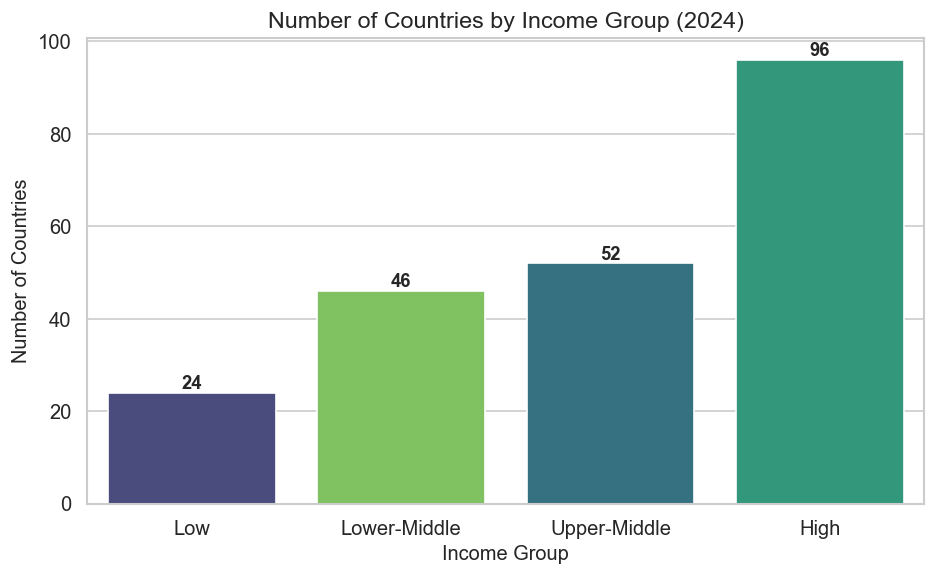

In [11]:
income_order = ['Low', 'Lower-Middle', 'Upper-Middle', 'High']
df_2024 = main_df.filter(pl.col("year") == 2024)

# convert to pandas for visualization
df_2024_pd = df_2024.to_pandas()

fig, ax = plt.subplots(figsize=(8, 5))
sns.countplot(data=df_2024_pd, x='income_group', order=income_order, palette='viridis', ax=ax, hue ='income_group')

ax.set_title('Number of Countries by Income Group (2024)')
ax.set_xlabel('Income Group')
ax.set_ylabel('Number of Countries')

# annotate bar counts
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

/var/folders/61/7lw43jz92wn9qxlh9cdtg5z80000gn/T/ipykernel_16725/1945263651.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(ax=ax1,


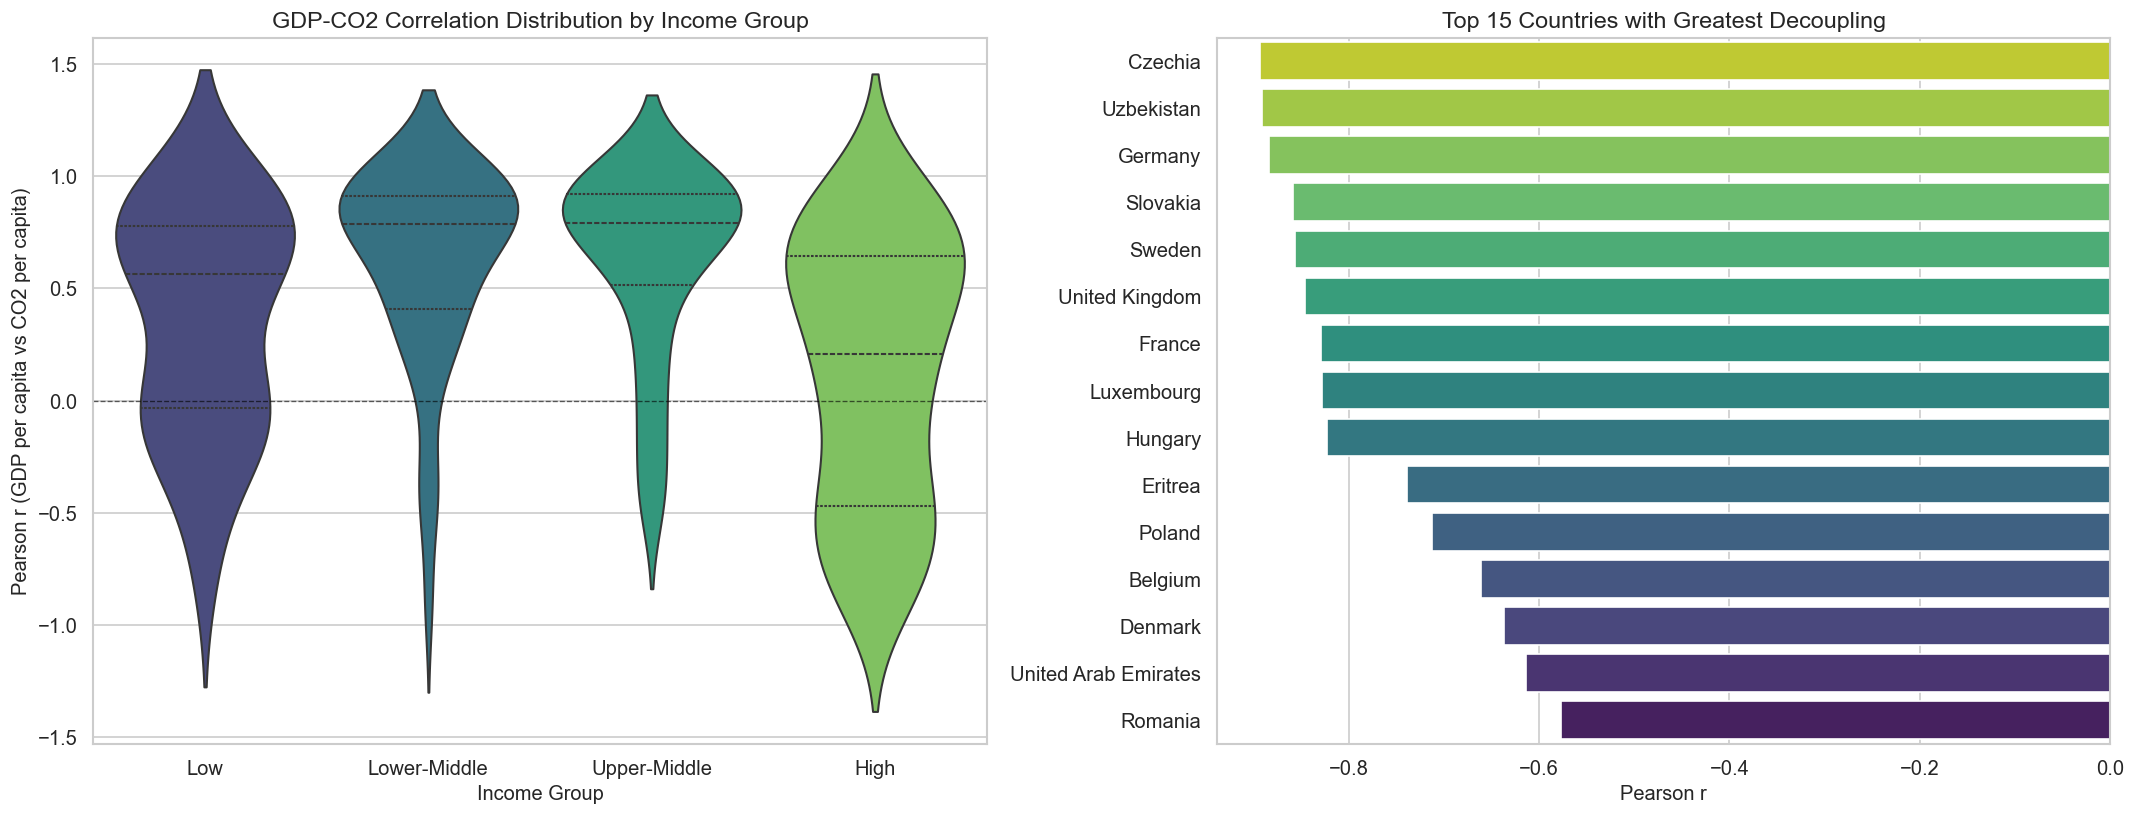

In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# violin plot: correlation distribution by income group
income_order = ['Low', 'Lower-Middle', 'Upper-Middle', 'High']

sns.violinplot(ax=ax1, 
               x='income_group', 
               y='correlation', 
               data=df_2024_pd,
               order=income_order, 
               palette='viridis', 
               inner='quartile')

ax1.set_title('GDP-CO2 Correlation Distribution by Income Group')
ax1.set_xlabel('Income Group')
ax1.set_ylabel('Pearson r (GDP per capita vs CO2 per capita)')
ax1.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.6)

# bar chart: top 15 decouplers (most negative correlation)
top_decouplers = get_top_bottom_n(df_2024_pd, 'correlation', n=15)
sns.barplot(ax=ax2, 
            x='correlation', 
            y='country', 
            data=top_decouplers,
            palette='viridis_r', 
            hue='country')
            
ax2.set_title('Top 15 Countries with Greatest Decoupling')
ax2.set_xlabel('Pearson r')
ax2.set_ylabel('')
ax2.axvline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# honestly I don't know how to get rid of this error message, I managed to fix it for every plot but nothing seems to work with the violin plot

### Interpreting the Results

The violin plot reveals how the GDP–CO2 correlation distributes within each income bracket. High-income countries show a wider spread with more negative correlations, suggesting that decoupling is more prevalent - and more varied - among wealthy nations. Lower-income groups cluster tightly around positive correlations, indicating that economic growth and emissions still move in tandem.

The bar chart of the top 15 decouplers (most negative Pearson r) surfaces some initially surprising entries - Uzbekistan and Czechia rank highly. However, this is consistent with the post-Soviet economic transition: many former Eastern Bloc countries experienced simultaneous GDP growth and emissions decline as they dismantled inefficient heavy industry inherited from the Soviet era and transitioned toward market economies with lighter industrial footprints.

The presence of the UAE among the top decouplers likely reflects its aggressive economic diversification away from oil dependency toward tourism, finance, and technology - sectors that generate GDP without proportional CO2 increases.

### Historical Emission Paths by Income Group
##### Note: Due to there not being a historical dataset I can't apply income groups to historical data. Income groups are referred to the current state of the countries 

The FacetGrid below plots per-capita CO2 over time, split into separate panels by income group. Each panel uses `sns.lineplot`, which computes the **mean** across all countries in that bracket along with a 95% confidence interval (shaded band).

We use separate panels rather than overlaying all four groups on a single axis for two reasons:
1. High-income countries emit orders of magnitude more per capita than low-income ones, which would compress the lower groups into flat lines at the bottom of a shared y-axis.
2. `sharey=False` gives each panel its own y-scale, allowing the internal trends within each group to be clearly visible.

**Key patterns to look for:**
- **High income**: A rise-then-decline trajectory - emissions peaked around the 1970s–2000s and have since been falling, consistent with deindustrialization, fuel switching, and policy intervention.
- **Upper-Middle**: Rapid growth phase, potentially still climbing as industrialization continues (driven heavily by China's trajectory in this bracket).
- **Lower-Middle / Low**: Flat, low emissions - these countries have contributed minimally to cumulative global CO2 despite housing large shares of the world's population.

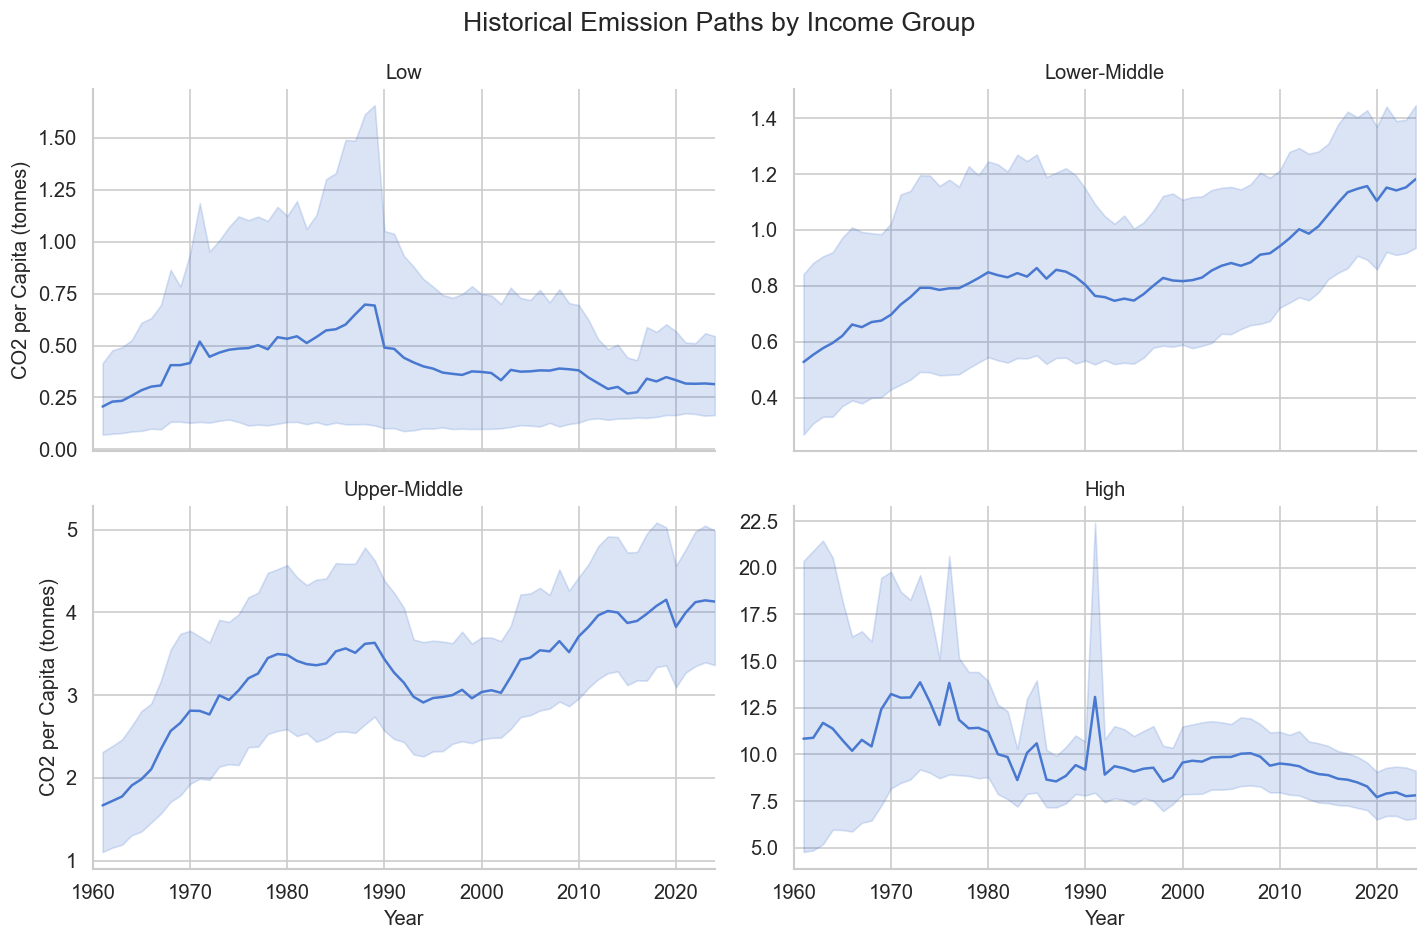

In [13]:
# compare historical emissions paths by income group
g = sns.FacetGrid(main_df, col="income_group", col_wrap=2, height=4, aspect=1.5,
                  sharey=False, col_order=['Low', 'Lower-Middle', 'Upper-Middle', 'High'])
g.map(sns.lineplot, "year", "co2_per_capita")

g.set(xlim=(1960, 2024))
g.set_axis_labels("Year", "CO2 per Capita (tonnes)")
g.set_titles("{col_name}")
plt.subplots_adjust(top=0.9)
g.fig.suptitle("Historical Emission Paths by Income Group", fontsize=16)
plt.show()

### Observations

The faceted emission trajectories confirm a clear structural divide:

- **High-income countries** show the classic inverted-U pattern (an Environmental Kuznets Curve shape) - emissions rose, peaked, and have since declined as economies shifted toward services and cleaner energy.
- **Upper-middle-income countries** display a notable growth. Mainly due to the rapid industrialization built on the basis of fossil fuels (China as main ambassador).
- **Lower-income groups** remain nearly flat throughout the entire period, underscoring the stark global inequality in both emissions responsibility and economic development.

This pattern supports the hypothesis that decoupling is largely a phenomenon of already-wealthy nations - those that have already passed through their most carbon-intensive growth phase.

In [14]:
# carbon intensity: CO2 (millions of tonnes) per $1M GDP
main_df = main_df.with_columns(
    pl.when(pl.col("gdp") != 0)
      .then(pl.col("co2") * 1_000_000 / pl.col("gdp"))
      .otherwise(None)
      .alias("co2_per_gdp"))

# keep working from the enriched dataframe from here on
# this way later cells still have income groups and carbon intensity
base_df = main_df.clone()

main_df


country,year,iso_code,population,co2,gdp,co2_per_capita,gdp_per_capita,log_gdp_pc,log_co2_pc,correlation,country_clean,gni_per_capita,income_group,co2_per_gdp
str,i64,str,i64,f64,f64,f64,f64,f64,f64,f64,str,f64,str,f64
"""Afghanistan""",1961,"""AFG""",9214082,0.491,null,0.053288,null,null,0.051917,0.9157,"""afghanistan""",370.0,"""Low""",null
"""Afghanistan""",1962,"""AFG""",9404410,0.689,null,0.073264,null,null,0.070704,0.9157,"""afghanistan""",370.0,"""Low""",null
"""Afghanistan""",1963,"""AFG""",9604491,0.707,null,0.073611,null,null,0.071028,0.9157,"""afghanistan""",370.0,"""Low""",null
"""Afghanistan""",1964,"""AFG""",9814317,0.839,null,0.085487,null,null,0.082029,0.9157,"""afghanistan""",370.0,"""Low""",null
"""Afghanistan""",1965,"""AFG""",10036003,1.007,null,0.100339,null,null,0.095618,0.9157,"""afghanistan""",370.0,"""Low""",null
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""Zimbabwe""",2020,"""ZWE""",15526887,8.491,3.1980e10,0.546858,2059.674586,7.630789,0.436226,-0.507579,"""zimbabwe""",2260.0,"""Lower-Middle""",0.000266
"""Zimbabwe""",2021,"""ZWE""",15797220,10.223,4.1288e10,0.647139,2613.603766,7.868868,0.49904,-0.507579,"""zimbabwe""",2260.0,"""Lower-Middle""",0.000248
"""Zimbabwe""",2022,"""ZWE""",16069061,12.232,4.0758e10,0.761214,2536.399713,7.838895,0.566004,-0.507579,"""zimbabwe""",2260.0,"""Lower-Middle""",0.0003


# Carbon Intensity: CO2 per $1 Million GDP

CO2 per GDP is an indicator of how efficient an economy is in terms of emissions. Typically we observe a downward trend, as technological advancements make economies more efficient while emitting less CO2.

We might also assume that richer, high-income countries are often the most efficient, due to their abundance of technological advancements and investments into greener production.

Due to countries like China, or the former Soviet states being in the upper-middle category, we can also expect them to be among the most carbon-intensive economies.

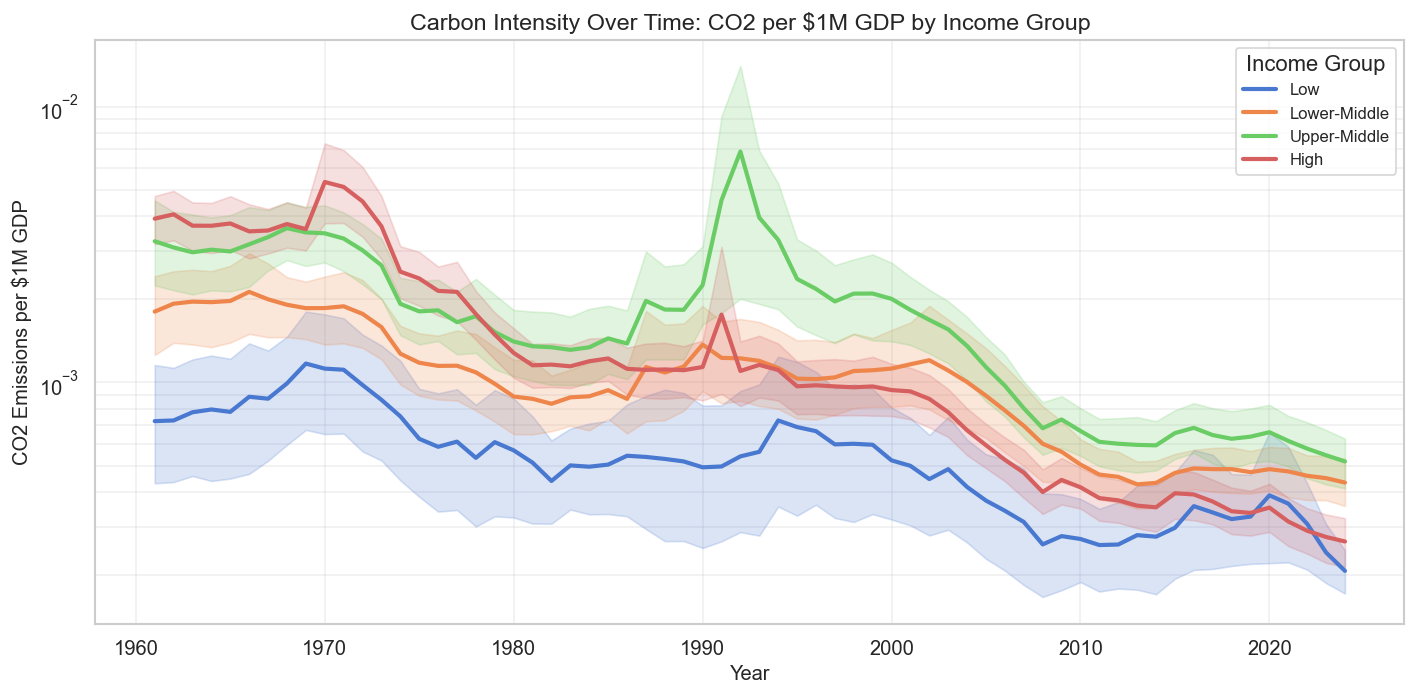

In [15]:
main_df_pd = main_df.to_pandas()

plt.figure(figsize=(12, 6))

sns.lineplot(data=main_df_pd, x='year', y='co2_per_gdp', hue='income_group',
             hue_order=['Low', 'Lower-Middle', 'Upper-Middle', 'High'],
             linewidth=2.5)

plt.yscale('log')
plt.title('Carbon Intensity Over Time: CO2 per $1M GDP by Income Group')
plt.xlabel('Year')
plt.ylabel('CO2 Emissions per $1M GDP')
plt.legend(title='Income Group')
plt.grid(True, which="both", ls="-", alpha=0.3)
plt.tight_layout()
plt.show()

As expected we see the Upper-Middle Income Group as the dominating force since the 1980, mainly due to the post-soviet/communist economies and countries like China, still relying on fossil fuels. We see a decline across almost all income groups in terms of CO2 per GDP, showing that technological advancements overall helped us being more efficient, especially notable in high income groups, due to the resources available to become more efficient.

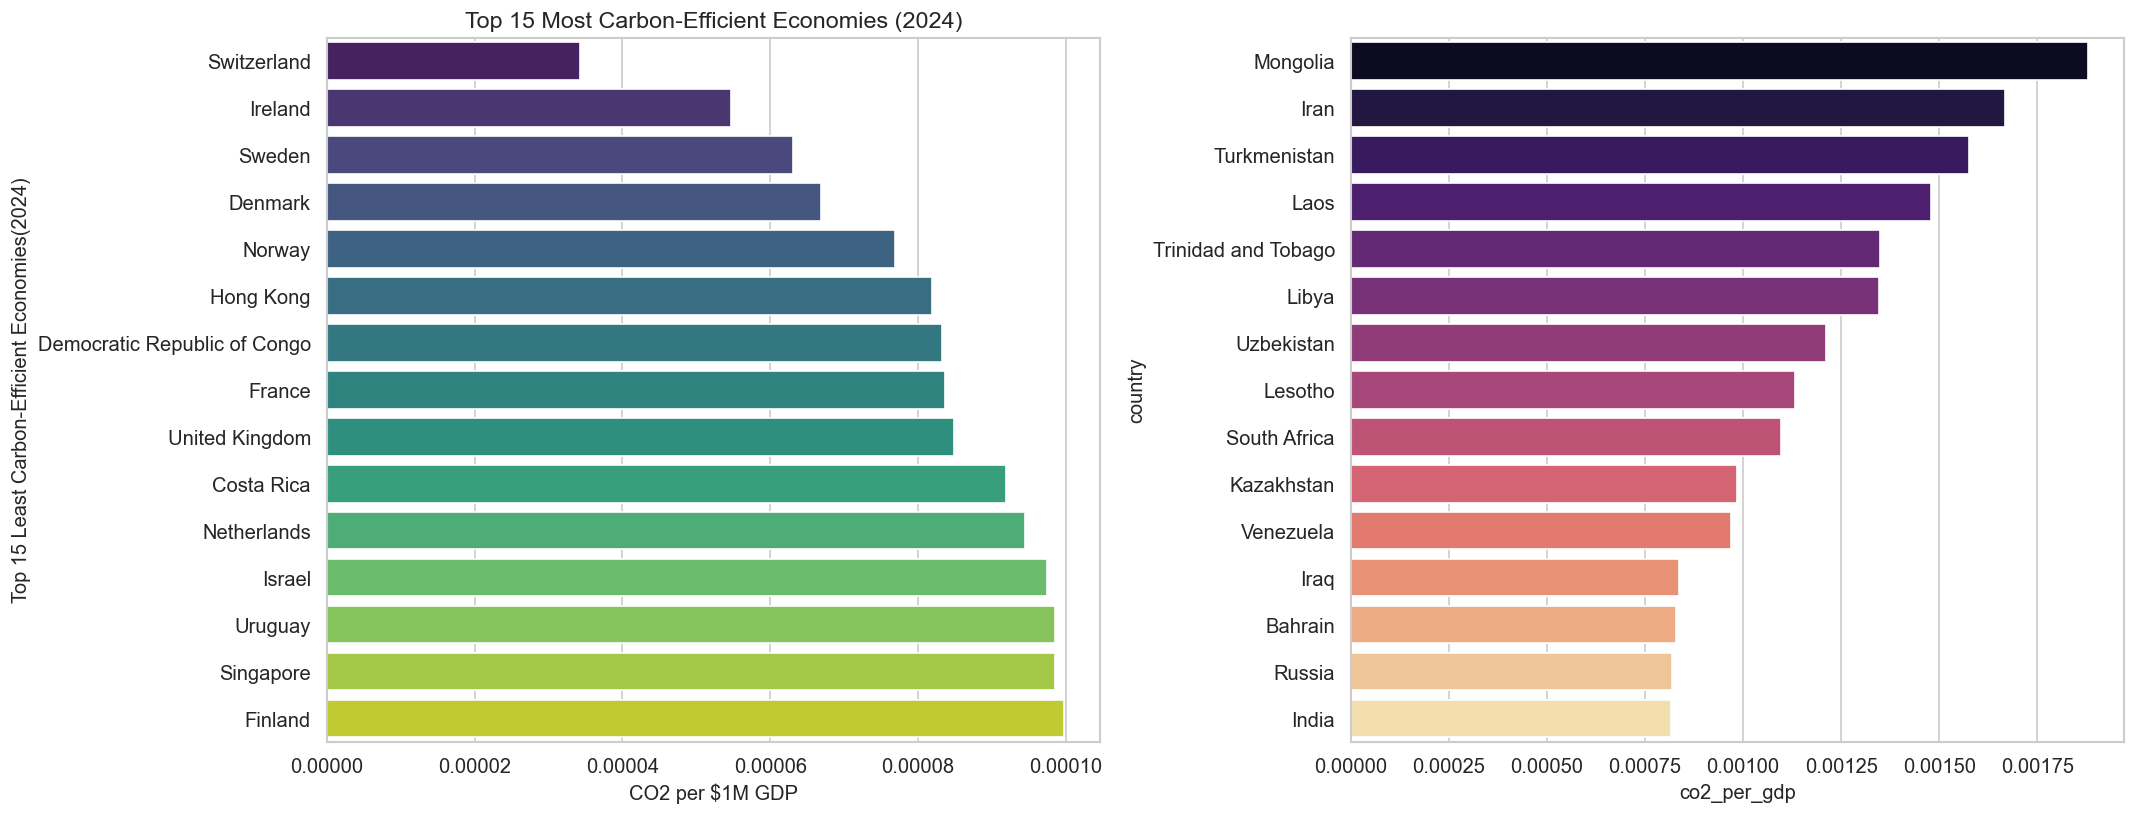

In [16]:
# filter: year 2024, population > 1M, valid co2_per_gdp
min_pop = 1_000_000

# fail early with a clearer message if a prep cell was skipped
if 'co2_per_gdp' not in base_df.columns:
    raise KeyError("Missing column 'co2_per_gdp'. Re-run the carbon-intensity cell above.")

df_efficient = base_df.filter(pl.col("year") == 2024,
                              pl.col("population") > min_pop,
                              pl.col("co2_per_gdp") > 0)
                       
# get the most and least efficient economies
df_efficient_pd = df_efficient.to_pandas()
most_efficient = get_top_bottom_n(df_efficient_pd, 'co2_per_gdp', n=15)
least_efficient = get_top_bottom_n(df_efficient_pd, 'co2_per_gdp', n=15, ascending=False)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# plot the most and least efficient economies
sns.barplot(ax=ax1, 
            x='co2_per_gdp', 
            y='country', 
            data=most_efficient, 
            palette='viridis', 
            hue='country', 
            legend=False)
            
ax1.set_title('Top 15 Most Carbon-Efficient Economies (2024)')
ax1.set_xlabel('CO2 per $1M GDP')
ax1.set_ylabel('Top 15 Least Carbon-Efficient Economies(2024)')

sns.barplot(
    ax=ax2, 
    x='co2_per_gdp', 
    y='country', 
    data=least_efficient, 
    palette='magma',
    hue='country',  
    legend=False)

plt.tight_layout()
plt.show()


We can observe the most carbon efficient economies mainly consisting of western democracies and well-developed states. Exceptions are: DRC and Costa Rica, the DRC probably being there due to their poverty, as well as most energy coming from hydro-powerplants.

The least efficient economies consist of 6 post-communist states and a collection of economies reliant on oil, coal, or gas-powerplants. Except for potentially Russia all of those countries are deemed to be developmental economies.

# Z-Score outlier visualisation

In [17]:

df_z = (
    main_df
    # filter for year, min pop and co2 per gdp
    .filter(
        (pl.col("year") == 2024) &
        (pl.col("population") > min_pop) &
        (pl.col("co2_per_gdp") > 0)
    )
    # only choose country and co2 per gdp
    .select(["country", "co2_per_gdp"])
    # calculate sigma and mu and save as z-score
    .with_columns(
        (
            (pl.col("co2_per_gdp") - pl.col("co2_per_gdp").mean()) /
            pl.col("co2_per_gdp").std()
        ).alias("z_score")
    )
)

# classify each country by z-score band
df_z = df_z.with_columns(
                    pl.when(pl.col("z_score").abs() > 3).then(pl.lit('Extreme (|z|>3)'))
                    .when(pl.col("z_score").abs() > 2).then(pl.lit('Outlier (|z|>2)'))
                    .when(pl.col("z_score").abs() > 1).then(pl.lit('Moderate (|z|>1)'))
                    .otherwise(pl.lit('Normal (|z|≤1)'))
                    .alias("Band"))
# sort for plotting
df_z = df_z.sort(pl.col("z_score"))

df_z



country,co2_per_gdp,z_score,Band
str,f64,f64,str
"""Switzerland""",0.000034,-1.038032,"""Moderate (|z|>1)"""
"""Ireland""",0.000055,-0.978179,"""Normal (|z|≤1)"""
"""Sweden""",0.000063,-0.953521,"""Normal (|z|≤1)"""
"""Denmark""",0.000067,-0.942625,"""Normal (|z|≤1)"""
"""Norway""",0.000077,-0.913155,"""Normal (|z|≤1)"""
…,…,…,…
"""Trinidad and Tobago""",0.001349,2.811568,"""Outlier (|z|>2)"""
"""Laos""",0.001479,3.191275,"""Extreme (|z|>3)"""
"""Turkmenistan""",0.001576,3.477839,"""Extreme (|z|>3)"""


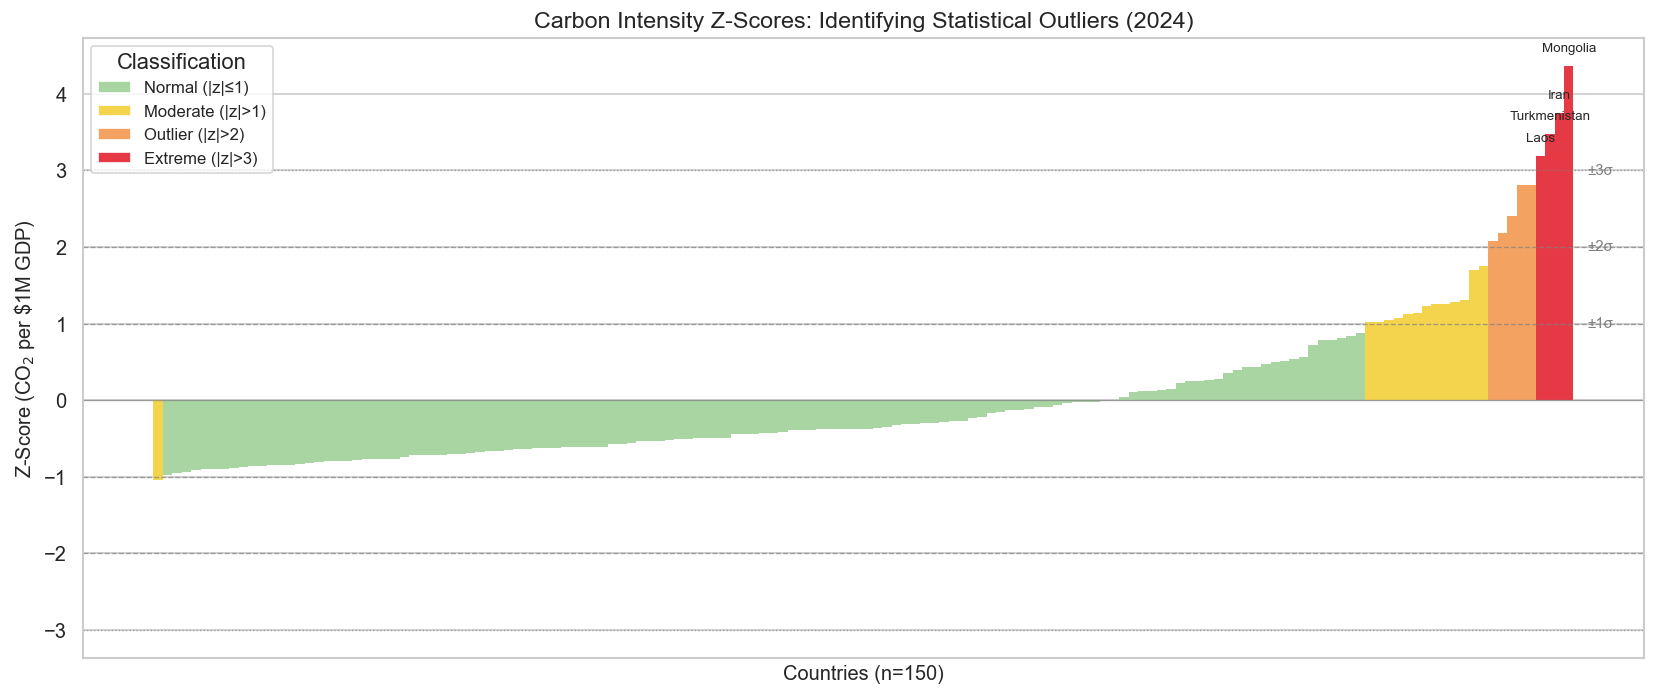

Outliers (|z|>2): 9 | Extreme (|z|>3): 4 of 150 countries


In [18]:
# convert to pandas for visualization
df_z_pd = df_z.to_pandas()

# plot
fig, ax = plt.subplots(figsize=(14, 6))

# create a palette for the bands
palette = {
    'Normal (|z|≤1)': '#a8d5a2',
    'Moderate (|z|>1)': '#f4d44d',
    'Outlier (|z|>2)': '#f4a261',
    'Extreme (|z|>3)': '#e63946'
}

ax.bar(range(len(df_z_pd)), df_z_pd['z_score'], color=df_z_pd['Band'].map(palette), width=1.0, edgecolor='none')

# z-score threshold bands
for z_val, ls, lbl in [(0, '-', 'Mean'), (1, '--', '±1σ'), (2, '--', '±2σ'), (3, ':', '±3σ')]:
    ax.axhline(z_val, color='grey', linestyle=ls, linewidth=0.8, alpha=0.7)
    if z_val > 0:
        ax.axhline(-z_val, color='grey', linestyle=ls, linewidth=0.8, alpha=0.7)
        ax.text(len(df_z_pd) + 1, z_val, lbl, va='center', fontsize=9, color='grey')

# label extreme outliers
for _, row in df_z_pd[np.abs(df_z_pd['z_score'].values) > 3].iterrows():
    idx = df_z_pd.index[df_z_pd['country'] == row['country']][0]
    ax.text(idx, row['z_score'] + np.sign(row['z_score']) * 0.15,
            row['country'], ha='center', va='bottom', fontsize=8)

ax.set_title('Carbon Intensity Z-Scores: Identifying Statistical Outliers (2024)')
ax.set_xlabel(f'Countries (n={len(df_z_pd)})')
ax.set_ylabel('Z-Score (CO$_2$ per \\$1M GDP)')
ax.set_xticks([])

# legend
legend_handles = [Patch(facecolor=c, label=l) for l, c in palette.items()]
ax.legend(handles=legend_handles, loc='upper left', title='Classification')

plt.tight_layout()
plt.show()

# summary statistics
n_outliers = np.sum(np.abs(df_z_pd['z_score'].values) > 2)
n_extreme = np.sum(np.abs(df_z_pd['z_score'].values) > 3)

print(f"Outliers (|z|>2): {n_outliers} | Extreme (|z|>3): {n_extreme} of {len(df_z)} countries")

### Interpreting Carbon Efficiency

**Most efficient economies** (lowest CO2 per $1M GDP):
Countries with service-dominated economies and minimal heavy industry naturally produce less CO2 per unit of economic output. Small island nations and financial centers top this list.

**Least efficient economies** (highest CO2 per $1M GDP):
Countries like Mongolia, Uzbekistan, Turkmenistan, and Kazakhstan are post-Soviet economies that rely heavily on coal for power generation - in some cases up to 90% of their electricity mix. This, combined with relatively low GDP, results in extremely high carbon intensity.